In [1]:
# ============================================================
# WEEK 10 PROJECT
# Customer Churn Prediction - Data Preprocessing & Feature Engineering
# Author: Meda Venkata Lakshmi Divya
# Environment: Google Colab
# ============================================================

# ------------------------------------------------
# Cell 1: Upload Dataset
# ------------------------------------------------

from google.colab import files

uploaded = files.upload()

# Upload:
# customer_churn.csv

Saving customer_churn.csv to customer_churn.csv


In [3]:
# ------------------------------------------------
# Cell 2: Import Required Libraries
# ------------------------------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
# ------------------------------------------------
# Cell 3: Load Dataset
# ------------------------------------------------

df = pd.read_csv("customer_churn.csv")

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [5]:
# ------------------------------------------------
# Cell 4: Explore Dataset
# ------------------------------------------------

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Dataset Shape: (500, 9)

Columns:
Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='object')

Data Types:
CustomerID          object
Tenure               int64
MonthlyCharges       int64
TotalCharges         int64
Contract            object
PaymentMethod       object
PaperlessBilling    object
SeniorCitizen        int64
Churn                int64
dtype: object

Missing Values:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

Duplicate Records:
0


In [7]:
# ------------------------------------------------
# Cell 5: Data Cleaning
# ------------------------------------------------

# Remove duplicate records
df = df.drop_duplicates()

# Convert TotalCharges into numeric format
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing numerical values using median
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values using mode
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Data cleaning completed successfully")

Data cleaning completed successfully


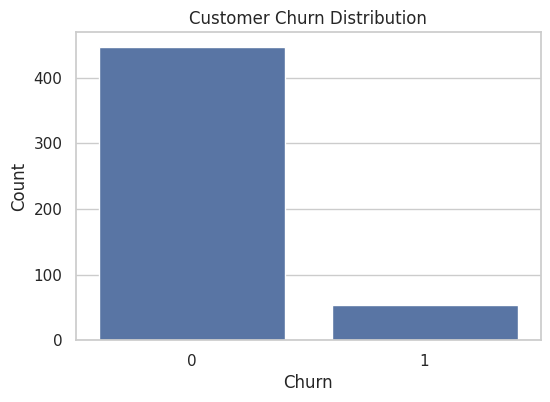

In [8]:
# ------------------------------------------------
# Cell 6: Churn Distribution
# ------------------------------------------------

plt.figure(figsize=(6, 4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

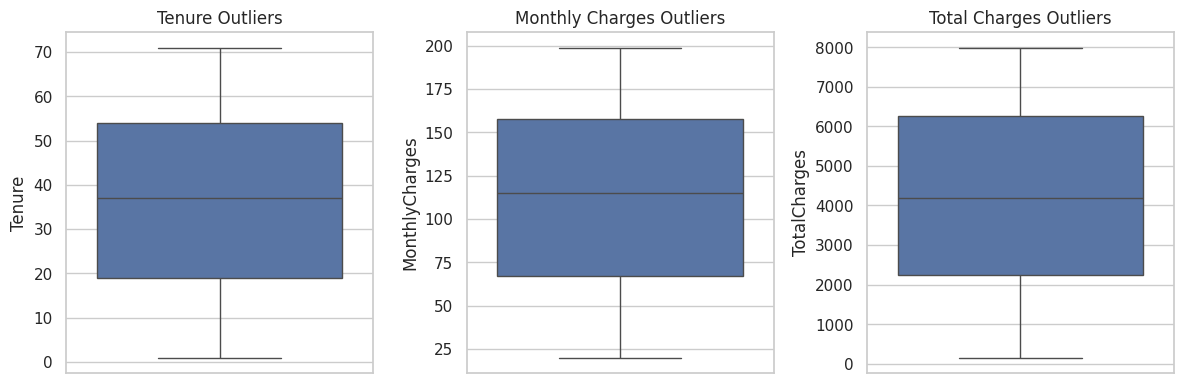

In [9]:
# ------------------------------------------------
# Cell 7: Outlier Detection using Boxplots
# ------------------------------------------------

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=df["Tenure"])
plt.title("Tenure Outliers")

plt.subplot(1, 3, 2)
sns.boxplot(y=df["MonthlyCharges"])
plt.title("Monthly Charges Outliers")

plt.subplot(1, 3, 3)
sns.boxplot(y=df["TotalCharges"])
plt.title("Total Charges Outliers")

plt.tight_layout()
plt.show()

In [10]:
# ------------------------------------------------
# Cell 8: Outlier Handling using IQR Method
# ------------------------------------------------

def cap_outliers_iqr(data, column):
    # Calculate Q1 and Q3
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Define lower and upper boundaries
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Cap outliers within boundaries
    data[column] = np.where(data[column] < lower_limit, lower_limit, data[column])
    data[column] = np.where(data[column] > upper_limit, upper_limit, data[column])

    return data

for col in ["Tenure", "MonthlyCharges", "TotalCharges"]:
    df = cap_outliers_iqr(df, col)

print("Outlier handling completed successfully")

Outlier handling completed successfully


In [11]:
# ------------------------------------------------
# Cell 9: Feature Engineering
# ------------------------------------------------

# Feature 1: Customer Lifetime Value
df["Customer_Lifetime_Value"] = df["Tenure"] * df["MonthlyCharges"]

# Feature 2: Average Revenue per Tenure
df["Avg_Revenue_Per_Tenure"] = df["TotalCharges"] / (df["Tenure"] + 1)

# Feature 3: Tenure Group
df["Tenure_Group"] = pd.cut(
    df["Tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"],
    include_lowest=True
)

# Feature 4: Monthly Charge Category
df["Monthly_Charge_Category"] = pd.cut(
    df["MonthlyCharges"],
    bins=3,
    labels=["Low Charge", "Medium Charge", "High Charge"]
)

# Feature 5: Contract Risk
df["Contract_Risk"] = np.where(
    df["Contract"] == "Month-to-month",
    "High Risk",
    "Low Risk"
)

# Feature 6: Digital Billing Flag
df["Digital_Billing_Flag"] = np.where(
    df["PaperlessBilling"] == "Yes",
    1,
    0
)

# Feature 7: High Value Customer
df["High_Value_Customer"] = np.where(
    df["TotalCharges"] > df["TotalCharges"].median(),
    1,
    0
)

print("Feature engineering completed successfully")
df.head()

Feature engineering completed successfully


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,Customer_Lifetime_Value,Avg_Revenue_Per_Tenure,Tenure_Group,Monthly_Charge_Category,Contract_Risk,Digital_Billing_Flag,High_Value_Customer
0,C00001,6.0,64.0,1540.0,One year,Credit Card,No,1,0,384.0,220.000000,0-12 Months,Low Charge,Low Risk,0,0
1,C00002,21.0,113.0,1753.0,Month-to-month,Electronic Check,Yes,1,0,2373.0,79.681818,13-24 Months,Medium Charge,High Risk,1,0
2,C00003,27.0,31.0,1455.0,Two year,Credit Card,No,1,0,837.0,51.964286,25-48 Months,Low Charge,Low Risk,0,0
3,C00004,53.0,29.0,7150.0,Month-to-month,Electronic Check,No,1,0,1537.0,132.407407,49-72 Months,Low Charge,High Risk,0,1
4,C00005,16.0,185.0,1023.0,One year,Electronic Check,No,1,0,2960.0,60.176471,13-24 Months,High Charge,Low Risk,0,0


In [12]:
# ------------------------------------------------
# Cell 10: Label Encoding
# ------------------------------------------------

label_df = df.copy()

label_encoder = LabelEncoder()

label_df["Contract_Label"] = label_encoder.fit_transform(label_df["Contract"])

print("Label Encoding applied successfully")
label_df[["Contract", "Contract_Label"]].head()

Label Encoding applied successfully


,Contract,Contract_Label
0,One year,1
1,Month-to-month,0
2,Two year,2
3,Month-to-month,0
4,One year,1


In [13]:
# ------------------------------------------------
# Cell 11: One-Hot Encoding
# ------------------------------------------------

one_hot_df = pd.get_dummies(
    df,
    columns=["PaymentMethod"],
    drop_first=True
)

print("One-Hot Encoding applied successfully")
one_hot_df.head()

One-Hot Encoding applied successfully


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaperlessBilling,SeniorCitizen,Churn,Customer_Lifetime_Value,Avg_Revenue_Per_Tenure,Tenure_Group,Monthly_Charge_Category,Contract_Risk,Digital_Billing_Flag,High_Value_Customer,PaymentMethod_Credit Card,PaymentMethod_Electronic Check
0,C00001,6.0,64.0,1540.0,One year,No,1,0,384.0,220.000000,0-12 Months,Low Charge,Low Risk,0,0,True,False
1,C00002,21.0,113.0,1753.0,Month-to-month,Yes,1,0,2373.0,79.681818,13-24 Months,Medium Charge,High Risk,1,0,False,True
2,C00003,27.0,31.0,1455.0,Two year,No,1,0,837.0,51.964286,25-48 Months,Low Charge,Low Risk,0,0,True,False
3,C00004,53.0,29.0,7150.0,Month-to-month,No,1,0,1537.0,132.407407,49-72 Months,Low Charge,High Risk,0,1,False,True
4,C00005,16.0,185.0,1023.0,One year,No,1,0,2960.0,60.176471,13-24 Months,High Charge,Low Risk,0,0,False,True


In [14]:
# ------------------------------------------------
# Cell 12: Ordinal Encoding
# ------------------------------------------------

ordinal_encoder = OrdinalEncoder(
    categories=[["Low Charge", "Medium Charge", "High Charge"]]
)

df["Monthly_Charge_Ordinal"] = ordinal_encoder.fit_transform(
    df[["Monthly_Charge_Category"]]
)

print("Ordinal Encoding applied successfully")
df[["Monthly_Charge_Category", "Monthly_Charge_Ordinal"]].head()

Ordinal Encoding applied successfully


,Monthly_Charge_Category,Monthly_Charge_Ordinal
0,Low Charge,0.0
1,Medium Charge,1.0
2,Low Charge,0.0
3,Low Charge,0.0
4,High Charge,2.0


In [15]:
# ------------------------------------------------
# Cell 13: Feature Scaling - StandardScaler
# ------------------------------------------------

standard_scaler = StandardScaler()

standard_scaled = standard_scaler.fit_transform(
    df[["Tenure", "MonthlyCharges", "TotalCharges"]]
)

standard_scaled_df = pd.DataFrame(
    standard_scaled,
    columns=["Tenure_Standard", "MonthlyCharges_Standard", "TotalCharges_Standard"]
)

standard_scaled_df.head()

,Tenure_Standard,MonthlyCharges_Standard,TotalCharges_Standard
0,-1.478807,-0.959185,-1.194621
1,-0.752287,-0.012290,-1.100305
2,-0.461679,-1.596890,-1.232259
3,0.797622,-1.635539,1.289485
4,-0.994460,1.379066,-1.423548


In [16]:
# ------------------------------------------------
# Cell 14: Feature Scaling - MinMaxScaler
# ------------------------------------------------

minmax_scaler = MinMaxScaler()

minmax_scaled = minmax_scaler.fit_transform(
    df[["Tenure", "MonthlyCharges", "TotalCharges"]]
)

minmax_scaled_df = pd.DataFrame(
    minmax_scaled,
    columns=["Tenure_MinMax", "MonthlyCharges_MinMax", "TotalCharges_MinMax"]
)

minmax_scaled_df.head()

,Tenure_MinMax,MonthlyCharges_MinMax,TotalCharges_MinMax
0,0.071429,0.245810,0.176305
1,0.285714,0.519553,0.203498
2,0.371429,0.061453,0.165454
3,0.742857,0.050279,0.892506
4,0.214286,0.921788,0.110303


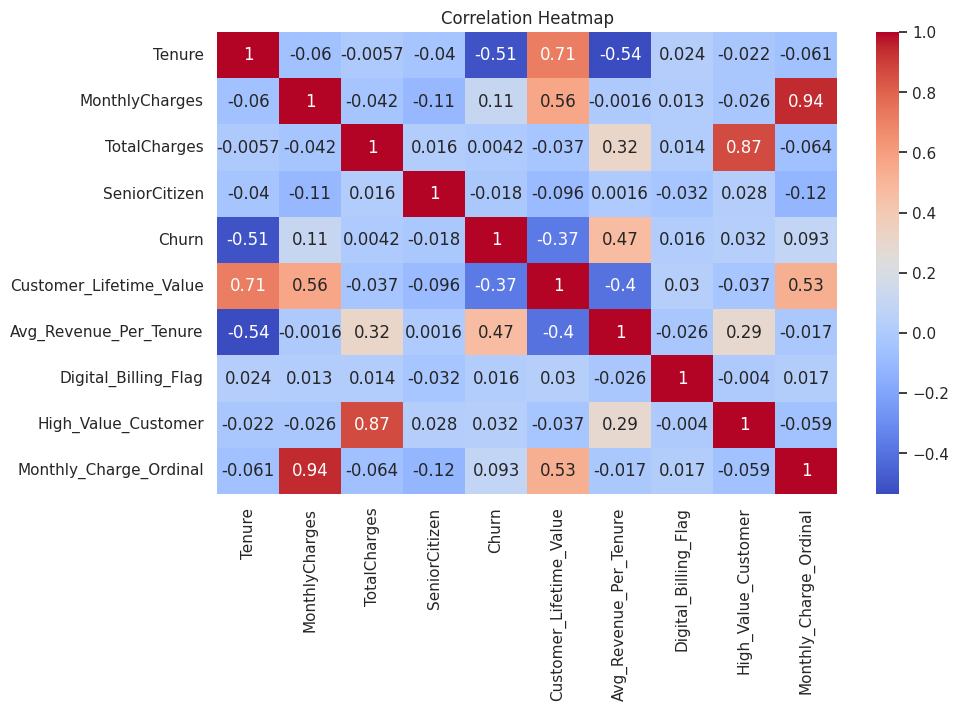

In [17]:
# ------------------------------------------------
# Cell 15: Correlation Heatmap
# ------------------------------------------------

plt.figure(figsize=(10, 6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
# ------------------------------------------------
# Cell 16: Prepare Features and Target
# ------------------------------------------------

# Drop CustomerID because it is an identifier, not a predictive feature
X = df.drop(["CustomerID", "Churn"], axis=1)

y = df["Churn"]

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Customer_Lifetime_Value', 'Avg_Revenue_Per_Tenure', 'Digital_Billing_Flag', 'High_Value_Customer', 'Monthly_Charge_Ordinal']

Categorical Features:
['Contract', 'PaymentMethod', 'PaperlessBilling', 'Tenure_Group', 'Monthly_Charge_Category', 'Contract_Risk']


In [19]:
# ------------------------------------------------
# Cell 17: Complete Preprocessing Pipeline
# ------------------------------------------------

# Pipeline for numerical features
numeric_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Pipeline for categorical features
categorical_pipeline = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully")

Preprocessing pipeline created successfully


In [20]:
# ------------------------------------------------
# Cell 18: Train-Test Split
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed successfully")

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Train-test split completed successfully
Training Shape: (400, 15)
Testing Shape : (100, 15)


In [21]:
# ------------------------------------------------
# Cell 19: Build Churn Prediction Pipeline
# ------------------------------------------------

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

# Train complete pipeline
model_pipeline.fit(X_train, y_train)

print("Churn prediction pipeline trained successfully")

Churn prediction pipeline trained successfully


In [22]:
# ------------------------------------------------
# Cell 20: Model Evaluation
# ------------------------------------------------

y_pred = model_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("=" * 60)
print("CUSTOMER CHURN PREDICTION REPORT")
print("=" * 60)

print(f"Accuracy Score: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

CUSTOMER CHURN PREDICTION REPORT
Accuracy Score: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        89
           1       1.00      0.55      0.71        11

    accuracy                           0.95       100
   macro avg       0.97      0.77      0.84       100
weighted avg       0.95      0.95      0.94       100



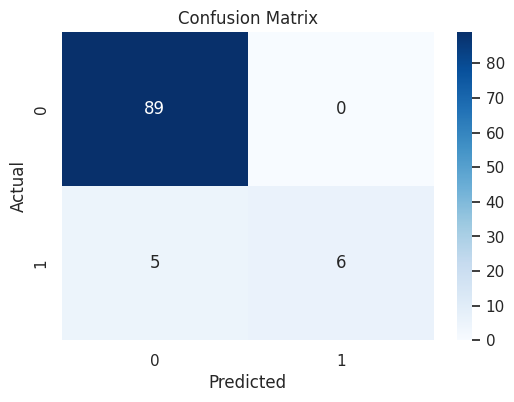

In [23]:
# ------------------------------------------------
# Cell 21: Confusion Matrix
# ------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
# ------------------------------------------------
# Cell 22: Final Summary
# ------------------------------------------------

print("=" * 70)
print("DATA PREPROCESSING & FEATURE ENGINEERING SUMMARY")
print("=" * 70)

print("Encoding Methods Used:")
print("1. Label Encoding")
print("2. One-Hot Encoding")
print("3. Ordinal Encoding")

print("\nScaling Techniques Used:")
print("1. Standard Scaling")
print("2. Min-Max Scaling")

print("\nEngineered Features Created:")
print("1. Customer_Lifetime_Value")
print("2. Avg_Revenue_Per_Tenure")
print("3. Tenure_Group")
print("4. Monthly_Charge_Category")
print("5. Contract_Risk")
print("6. Digital_Billing_Flag")
print("7. High_Value_Customer")

print("\nModel Accuracy:")
print(f"{accuracy:.2f}")

print("=" * 70)

DATA PREPROCESSING & FEATURE ENGINEERING SUMMARY
Encoding Methods Used:
1. Label Encoding
2. One-Hot Encoding
3. Ordinal Encoding

Scaling Techniques Used:
1. Standard Scaling
2. Min-Max Scaling

Engineered Features Created:
1. Customer_Lifetime_Value
2. Avg_Revenue_Per_Tenure
3. Tenure_Group
4. Monthly_Charge_Category
5. Contract_Risk
6. Digital_Billing_Flag
7. High_Value_Customer

Model Accuracy:
0.95
